# NSE Index-Futures LOB — Exploratory Data Analysis

This notebook characterises the **engineered NSE index-futures dataset** (NIFTY front-month, Dhan twenty-depth
feed) that underpins the capstone. It is self-contained: it pulls a few training days directly from S3 and
produces the four EDA figures used in the report.

**What we look at**
1. **Label distribution by horizon** — how the Down/Stationary/Up balance shifts with the prediction horizon.
2. **Inter-tick gap** — the update cadence of the stored feed.
3. **Relative bid–ask spread** — the cost floor that drives the labelling-threshold study.
4. **Intraday mid-price trace** — the non-stationary character of a session.

**Key finding (and an honest correction):** the stored Dhan feed is a *regular* ~0.4 s (~2.5 Hz) cadence
(CV ≈ 0.34), **not** the heavy-tailed "event-driven" stream an early 15-minute probe suggested. The collector
writes one row per server push with no timer, so this cadence is the Dhan server's push rate — a genuine
difference from FI-2010's true per-event ticks.

**Setup:** needs `AWS_ACCESS_KEY_ID` / `AWS_SECRET_ACCESS_KEY` (as Kaggle/Colab secrets or env vars). No GPU.


## 1. Install dependencies

In [1]:
import subprocess, sys
def pipq(*pkgs): subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
pipq("boto3", "pandas", "pyarrow", "matplotlib")
import boto3, pandas as pd, numpy as np, matplotlib
print("boto3", boto3.__version__, "| pandas", pd.__version__)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
awscli 1.45.17 requires s3transfer<0.19.0,>=0.18.0, but you have s3transfer 0.17.1 which is incompatible.


boto3 1.43.0 | pandas 2.3.3


## 2. Credentials (Kaggle / Colab secret, or environment)

In [2]:
import os, time
_SECRET_CACHE = {}
def get_secret(name):
    if _SECRET_CACHE.get(name): return _SECRET_CACHE[name]
    for attempt in range(4):
        try:
            from kaggle_secrets import UserSecretsClient
            v = UserSecretsClient().get_secret(name)
            if v: _SECRET_CACHE[name] = v; return v
        except Exception:
            time.sleep(5 * (attempt + 1))
        try:
            from google.colab import userdata
            v = userdata.get(name)
            if v: _SECRET_CACHE[name] = v; return v
        except Exception:
            pass
        break
    return os.environ.get(name, "")
for _k in ("AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY"):
    _v = get_secret(_k)
    if _v: os.environ[_k] = _v          # don't clobber a local ~/.aws default chain with empty strings
print("AWS creds available:", bool(os.environ.get("AWS_ACCESS_KEY_ID")) or "via default credential chain")

AWS creds available: via default credential chain


## 3. Load NSE data from S3 (NIFTY, a few training days)

In [3]:
import io, boto3, numpy as np, pandas as pd
BUCKET, REGION = "lob-capstone-data", "ap-south-2"
SYMBOL = "NIFTY"
DAYS = ["20260512", "20260513", "20260514", "20260515", "20260518"]   # training days
s3 = boto3.client("s3", region_name=REGION)

def load_day(d):
    key = f"lob-data/dhan/lob_dhan_{d}.parquet"
    buf = io.BytesIO(s3.get_object(Bucket=BUCKET, Key=key)["Body"].read())
    df = pd.read_parquet(buf)
    df = df[df["symbol"].astype(str).str.startswith(SYMBOL)].copy()   # front-month root
    df = df[df["bid_price_1"] < df["ask_price_1"]]                    # drop crossed quotes
    df["ts"] = pd.to_datetime(df["timestamp"], format="ISO8601")
    return df.sort_values("ts").reset_index(drop=True)

days = {d: load_day(d) for d in DAYS}
for d, dfx in days.items():
    print(f"{d}: {len(dfx):,} {SYMBOL} events")

# concat with per-day segment ids (labels never cross a day / contract boundary)
frames, segs = [], []
for i, d in enumerate(DAYS):
    frames.append(days[d]); segs.append(np.full(len(days[d]), i))
df = pd.concat(frames, ignore_index=True)
seg = np.concatenate(segs)
mid = ((df["bid_price_1"] + df["ask_price_1"]) / 2).values
spread = (df["ask_price_1"] - df["bid_price_1"]).values
rel_spread_bps = spread / mid * 1e4
print(f"\ntotal {len(df):,} events across {len(DAYS)} days")

20260512: 56,597 NIFTY events
20260513: 57,649 NIFTY events
20260514: 57,049 NIFTY events
20260515: 60,421 NIFTY events
20260518: 57,756 NIFTY events

total 289,472 events across 5 days


## 4. Labelling function
This mirrors `modeling/nse_dataset.py::_make_labels` exactly, so the label distribution below matches what the
models were trained on. Labels use the FI-2010 smoothed-mid convention with a fixed threshold $\alpha$
(Scheme A), computed independently within each trading day (segment).

In [4]:
def make_labels(mid, k, alpha, seg=None):
    """FI-2010 smoothed-mid labels: 0=Down, 1=Stat, 2=Up, -1=edge. Per-segment if seg given."""
    if seg is not None:
        labels = np.full(len(mid), -1, dtype=np.int8)
        for s in np.unique(seg):
            m = seg == s
            labels[m] = make_labels(mid[m], k=k, alpha=alpha)
        return labels
    n = len(mid)
    cs = np.concatenate([[0.0], np.cumsum(mid)])
    idx = np.arange(n)
    m_behind = np.full(n, np.nan); valid_b = idx >= k - 1
    m_behind[valid_b] = (cs[idx[valid_b] + 1] - cs[idx[valid_b] - k + 1]) / k
    m_ahead = np.full(n, np.nan); valid_a = idx + k < n
    m_ahead[valid_a] = (cs[idx[valid_a] + k + 1] - cs[idx[valid_a] + 1]) / k
    valid = valid_a & valid_b
    r = np.full(n, np.nan); r[valid] = (m_ahead[valid] - m_behind[valid]) / m_behind[valid]
    labels = np.full(n, -1, dtype=np.int8)
    labels[valid & (r > alpha)] = 2
    labels[valid & (r < -alpha)] = 0
    labels[valid & (r >= -alpha) & (r <= alpha)] = 1
    return labels
print("labeller ready")

labeller ready


## 5. Label distribution by horizon (Scheme A, $\alpha{=}10^{-5}$)

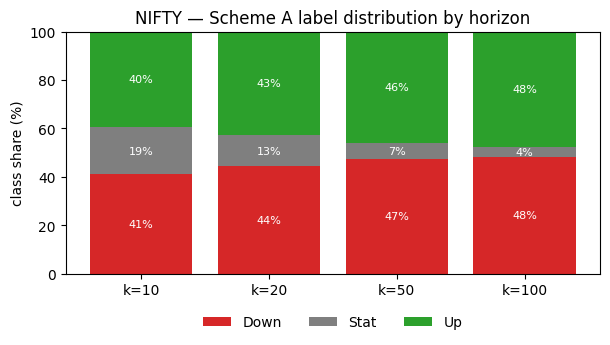

k= 10: Down 41.0%  Stat 19.4%  Up 39.5%
k= 20: Down 44.4%  Stat 12.7%  Up 42.9%
k= 50: Down 47.3%  Stat 6.6%  Up 46.1%
k=100: Down 48.3%  Stat 4.0%  Up 47.7%


In [5]:
import matplotlib.pyplot as plt
CLASSES = ["Down", "Stat", "Up"]; COLORS = ["#d62728", "#7f7f7f", "#2ca02c"]
horizons = [10, 20, 50, 100]
props = []
for k in horizons:
    lab = make_labels(mid, k=k, alpha=1e-5, seg=seg); lab = lab[lab >= 0]
    props.append(np.bincount(lab, minlength=3) / len(lab) * 100)
props = np.array(props)
fig, ax = plt.subplots(figsize=(6.2, 3.6)); bottom = np.zeros(len(horizons)); x = np.arange(len(horizons))
for c in range(3):
    ax.bar(x, props[:, c], bottom=bottom, label=CLASSES[c], color=COLORS[c])
    for xi in x:
        if props[xi, c] > 4:
            ax.text(xi, bottom[xi] + props[xi, c] / 2, f"{props[xi,c]:.0f}%", ha="center", va="center",
                    fontsize=8, color="white")
    bottom += props[:, c]
ax.set_xticks(x); ax.set_xticklabels([f"k={k}" for k in horizons]); ax.set_ylim(0, 100)
ax.set_ylabel("class share (%)"); ax.set_title(f"{SYMBOL} — Scheme A label distribution by horizon")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)
plt.tight_layout(); plt.savefig("eda_label_dist.png", dpi=150, bbox_inches="tight"); plt.show()
for k, p in zip(horizons, props): print(f"k={k:3d}: Down {p[0]:.1f}%  Stat {p[1]:.1f}%  Up {p[2]:.1f}%")

**Observation.** The Stationary class shrinks from ~19% at $k{=}10$ to ~4% at $k{=}100$: at long horizons
almost every mid-price move clears the fixed threshold, so the task becomes effectively binary (Down/Up). This
is why macro- and weighted-$F_1$ converge at long horizons in the results.

## 6. Inter-tick gap — the update cadence

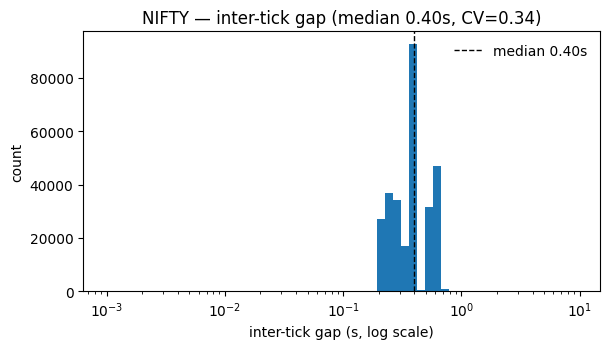

events/min ~ 154 | median gap 0.398s | p99 0.60s | CV 0.34


In [6]:
import numpy as np, matplotlib.pyplot as plt
gaps, ev_per_min = [], []
for d in DAYS:
    g = days[d]["ts"].diff().dt.total_seconds().dropna().values
    g = g[(g > 0) & (g < 300)]                       # drop nonpositive + genuine feed outages
    gaps.append(g)
    span = (days[d]["ts"].iloc[-1] - days[d]["ts"].iloc[0]).total_seconds() / 60
    ev_per_min.append(len(days[d]) / span)
gaps = np.concatenate(gaps); cv = gaps.std() / gaps.mean()
fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.hist(gaps, bins=np.logspace(np.log10(max(gaps.min(),1e-3)), np.log10(gaps.max()), 60), color="#1f77b4")
ax.set_xscale("log"); ax.axvline(np.median(gaps), color="k", ls="--", lw=1, label=f"median {np.median(gaps):.2f}s")
ax.set_xlabel("inter-tick gap (s, log scale)"); ax.set_ylabel("count")
ax.set_title(f"{SYMBOL} — inter-tick gap (median {np.median(gaps):.2f}s, CV={cv:.2f})"); ax.legend(frameon=False)
plt.tight_layout(); plt.savefig("eda_intertick.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"events/min ~ {np.mean(ev_per_min):.0f} | median gap {np.median(gaps):.3f}s | p99 {np.percentile(gaps,99):.2f}s | CV {cv:.2f}")

**Observation (the honest correction).** Gaps are tightly clustered in 0.2–0.7 s (median ~0.40 s,
$p_{99}$ ~0.60 s, **CV ~0.34**) — a *regular* ~2.5 Hz cadence, **not** heavy-tailed. The production collector
(`collect_dhan.py`) writes one row per WebSocket push with no timer, so this is the Dhan **server's** push
rate. An earlier 15-minute multi-instrument probe reported CV ~3.3; that did not reflect the stored
single-instrument training data, and the report was corrected to these numbers. The near-periodic cadence is
a real difference from FI-2010's true per-event ticks and partly explains the lower absolute NSE accuracy.

## 7. Relative bid–ask spread

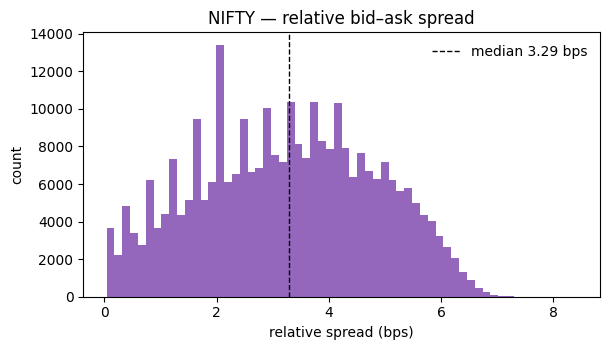

median relative spread 3.29 bps


In [7]:
import numpy as np, matplotlib.pyplot as plt
rs = rel_spread_bps[(rel_spread_bps > 0) & (rel_spread_bps < 20)]
fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.hist(rs, bins=60, color="#9467bd")
ax.axvline(np.median(rs), color="k", ls="--", lw=1, label=f"median {np.median(rs):.2f} bps")
ax.set_xlabel("relative spread (bps)"); ax.set_ylabel("count")
ax.set_title(f"{SYMBOL} — relative bid–ask spread"); ax.legend(frameon=False)
plt.tight_layout(); plt.savefig("eda_spread.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"median relative spread {np.median(rs):.2f} bps")

**Observation.** The median relative spread is ~3.3 bps. Because the horizon-$k$ mid-price move is often
smaller than the spread, a *fixed* threshold (Scheme A) and a *spread-relative* threshold (Scheme B) define
very different tasks — motivating the labelling-scheme study in the results.

## 8. Intraday mid-price trace

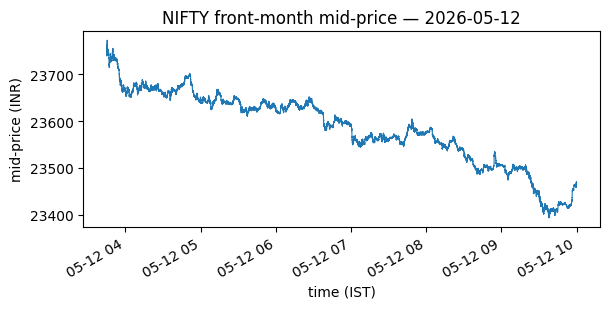

56,597 events | range 23394-23772


In [8]:
import matplotlib.pyplot as plt
d0 = DAYS[0]; dd = days[d0]
mid0 = ((dd["bid_price_1"] + dd["ask_price_1"]) / 2).values
fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.plot(dd["ts"].values, mid0, color="#1f77b4", lw=0.8)
ax.set_xlabel("time (IST)"); ax.set_ylabel("mid-price (INR)")
ax.set_title(f"{SYMBOL} front-month mid-price — {d0[:4]}-{d0[4:6]}-{d0[6:]}")
fig.autofmt_xdate(); plt.tight_layout(); plt.savefig("eda_midprice.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"{len(mid0):,} events | range {mid0.min():.0f}-{mid0.max():.0f}")

**Observation.** A single session trends and mean-reverts on multiple scales — the non-stationary
behaviour that makes short-horizon LOB prediction hard and motivates sequence models over static classifiers.

---
### Summary
| Property | Value (NIFTY, training days) |
|---|---|
| Events / min | ~154 |
| Inter-tick gap | median ~0.40 s, CV ~0.34 (regular ~2.5 Hz) |
| Relative spread | median ~3.3 bps |
| Stationary share | ~19% (k=10) → ~4% (k=100) |

These four figures are the EDA artifacts embedded in §3.4.3 of the report.